# Long-Term Analysis

In [1]:
import cmocean.cm as cm
import copy
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.colors as mcolors
#
from shapely.geometry import Polygon, Point
from shapely.plotting import plot_polygon
from matplotlib.path import Path
from matplotlib.colors import ListedColormap
from scipy.optimize import curve_fit
mask = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc')

In [2]:
def volume_region_50m_bottom(polygon):
    mesh = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc')
    volume = mesh['volume']
    mask = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc')['tmask'][0]
    #
    depths = mesh['gdept_1d'][0] 
    depth_condition = depths >= 50
    # 
    depth_mask_3d = depth_condition.values[:, np.newaxis, np.newaxis]
    #    
    x = volume['x']  
    y = volume['y'] 
    #
    xx, yy = np.meshgrid(x, y)
    #
    # 2D Polygon Mask
    polygon_mask_2d = np.array([
        [polygon.contains(Point(xx[j, i], yy[j, i])) for i in range(len(x))]
        for j in range(len(y))
    ])

    # to 3D
    nz = volume.sizes['z']
    polygon_mask_3d = np.repeat(polygon_mask_2d[np.newaxis, :, :], nz, axis=0)

    # inside polygon  + in water + > 50 m
    combined_mask = (polygon_mask_3d & (mask.values == 1) & depth_mask_3d)

    # Applying mask
    mask_da = xr.DataArray(combined_mask, dims=volume.dims, coords=volume.coords)
    volume_in_polygon_water = volume.where(mask_da).sum().item()
    
    return volume_in_polygon_water

In [3]:
import long_term_functions

In [4]:
PBDEs_min = pd.read_csv('PBDEs_min_predicted_discharge.csv')
PBDEs_max = pd.read_csv('PBDEs_max_predicted_discharge.csv')

In [5]:
max_year = 2050

In [6]:
column_names = [
    'Year 0', 'Year 1', 'Year 2', 'Year 3', 'Year 4', 'Year 5', 'Year 6', 'Year 7', 'Year 8', 'Year 9', 'Year 10', 'Year 11', 'Year 12'
]

In [7]:
time_x = np.arange(1970, max_year+1, 1/(8*365))

In [8]:
total_BDE_47_min, total_BDE_47_max = long_term_functions.total_pool_tseries(congener_min=PBDEs_min, congener_max=PBDEs_max, BDE_name = 'BDE-47')

min_BDE_47 = pd.DataFrame(dict(zip(column_names, total_BDE_47_min)))
max_BDE_47 = pd.DataFrame(dict(zip(column_names, total_BDE_47_max)))

In [9]:
total_BDE_99_min, total_BDE_99_max = long_term_functions.total_pool_tseries(congener_min=PBDEs_min, congener_max=PBDEs_max, BDE_name = 'BDE-99')

min_BDE_99 = pd.DataFrame(dict(zip(column_names, total_BDE_99_min)))
max_BDE_99 = pd.DataFrame(dict(zip(column_names, total_BDE_99_max)))

In [10]:
total_BDE_209_min, total_BDE_209_max = long_term_functions.total_pool_tseries(congener_min=PBDEs_min, congener_max=PBDEs_max, BDE_name = 'BDE-209')

min_BDE_209 = pd.DataFrame(dict(zip(column_names, total_BDE_209_min)))
max_BDE_209 = pd.DataFrame(dict(zip(column_names, total_BDE_209_max)))

Text(0.5, 1.0, 'Minimum and Maximum estimated PBDEs pool after 13 years release from Iona Outfall')

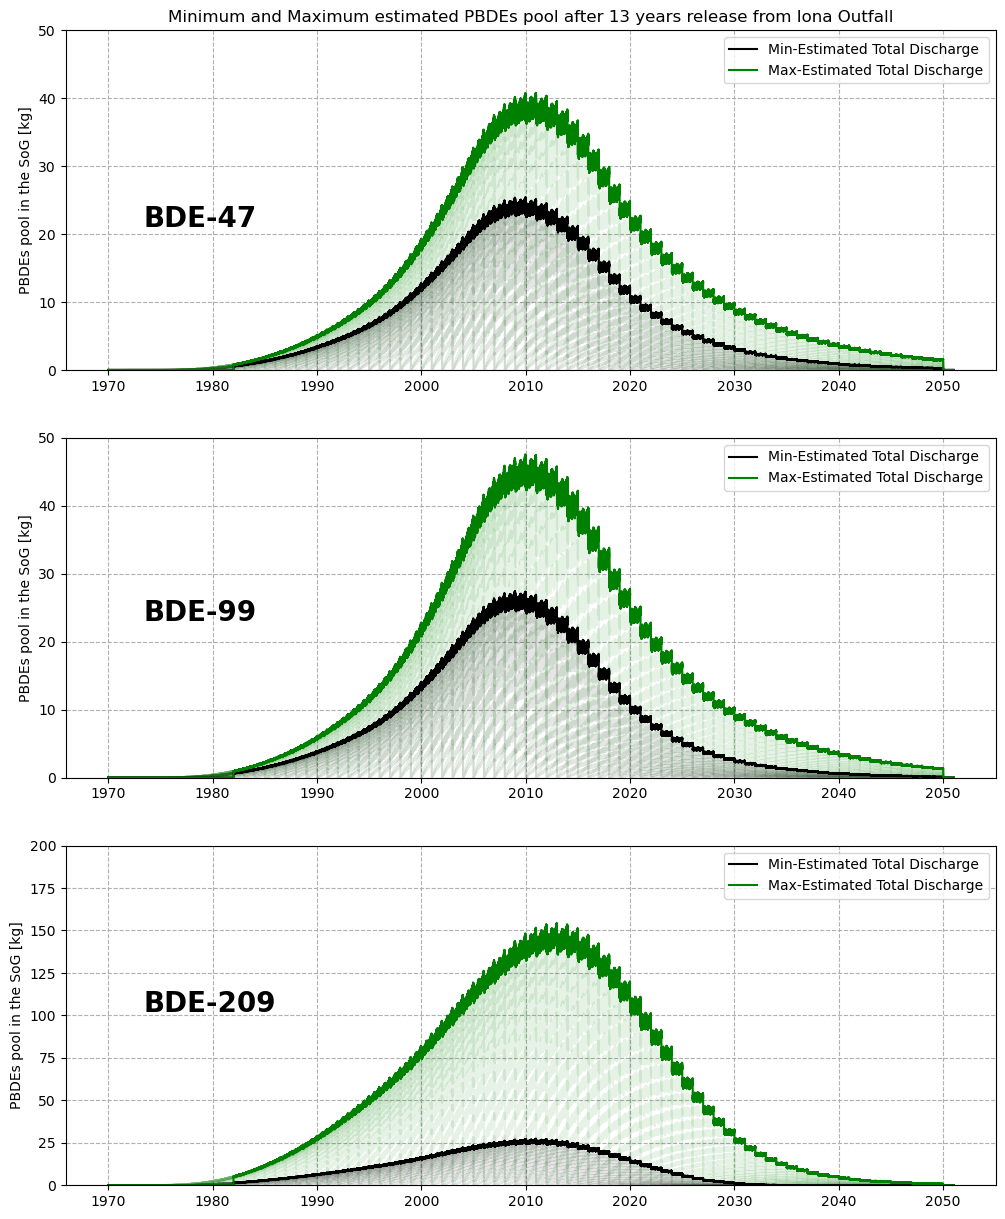

In [11]:
fig, ax = plt.subplots(3,1, figsize = (12, 15))
ax[0].plot(time_x, min_BDE_47/1000, 'k', alpha = .1)
ax[0].plot(time_x, max_BDE_47/1000, 'g', alpha = .1)
ax[0].plot(time_x, min_BDE_47['Year 12']/1000, 'k', label = 'Min-Estimated Total Discharge')
ax[0].plot(time_x, max_BDE_47['Year 12']/1000, 'g', label = 'Max-Estimated Total Discharge')
ax[0].set_ylim(0,50)
ax[0].text(time_x[10000],int(max_BDE_47['Year 12'].max()/1000/1.9),'BDE-47', fontsize = 20, fontweight='bold')

#
ax[1].plot(time_x, min_BDE_99/1000, 'k', alpha = .1)
ax[1].plot(time_x, max_BDE_99/1000, 'g', alpha = .1)
ax[1].plot(time_x, min_BDE_99['Year 12']/1000, 'k', label = 'Min-Estimated Total Discharge')
ax[1].plot(time_x, max_BDE_99['Year 12']/1000, 'g', label = 'Max-Estimated Total Discharge')
ax[1].set_ylim(0,50)
ax[1].text(time_x[10000],int(max_BDE_99['Year 12'].max()/1000/2),'BDE-99', fontsize = 20, fontweight='bold')

#
ax[2].plot(time_x, min_BDE_209/1000, 'k', alpha = .1)
ax[2].plot(time_x, max_BDE_209/1000, 'g', alpha = .1)
ax[2].plot(time_x, min_BDE_209['Year 12']/1000, 'k', label = 'Min-Estimated Total Discharge')
ax[2].plot(time_x, max_BDE_209['Year 12']/1000, 'g', label = 'Max-Estimated Total Discharge')
ax[2].set_ylim(0,200)
ax[2].text(time_x[10000],int(max_BDE_209['Year 12'].max()/1000/1.5),'BDE-209', fontsize = 20, fontweight='bold')

#
for axis in ax:
    axis.grid(linestyle = '--')
    axis.legend(loc = 'upper right')
    axis.set_ylabel('PBDEs pool in the SoG [kg]')

ax[0].set_title('Minimum and Maximum estimated PBDEs pool after 13 years release from Iona Outfall')    

Extrapolation from Total

In [12]:
total_predicted_BDE_47_min, total_predicted_BDE_47_max = long_term_functions.extrapolation_total(congener_min=PBDEs_min, congener_max=PBDEs_max, BDE_name = 'BDE-47')
predicted_min_BDE_47 = pd.DataFrame(total_predicted_BDE_47_min, columns = ['BDE-47'])
predicted_max_BDE_47 = pd.DataFrame(total_predicted_BDE_47_max, columns = ['BDE-47'])

In [13]:
total_predicted_BDE_99_min, total_predicted_BDE_99_max = long_term_functions.extrapolation_total(congener_min=PBDEs_min, congener_max=PBDEs_max, BDE_name = 'BDE-99')
predicted_min_BDE_99 = pd.DataFrame(total_predicted_BDE_99_min, columns = ['BDE-99'])
predicted_max_BDE_99 = pd.DataFrame(total_predicted_BDE_99_max, columns = ['BDE-99'])

In [14]:
total_predicted_BDE_209_min, total_predicted_BDE_209_max = long_term_functions.extrapolation_total(congener_min=PBDEs_min, congener_max=PBDEs_max, BDE_name = 'BDE-209')
predicted_min_BDE_209 = pd.DataFrame(total_predicted_BDE_209_min, columns = ['BDE-209'])
predicted_max_BDE_209 = pd.DataFrame(total_predicted_BDE_209_max, columns = ['BDE-209'])

# Region S1

In [15]:
from Regions_functions_V2 import polygon_S1, polygon_lon_lat_S1

In [16]:
volume_S1 = volume_region_50m_bottom(polygon_S1)

In [17]:
time_S1 = np.arange(1970, max_year+1, 1/(4*365))

In [18]:
S1_BDE_47_min, S1_BDE_47_max = long_term_functions.regions_tseries(congener_min=PBDEs_min, congener_max=PBDEs_max, polygon_lon_lat=polygon_lon_lat_S1, BDE_name='BDE-47')
#
min_BDE_47_S1 = pd.DataFrame(dict(zip(column_names, S1_BDE_47_min)))
max_BDE_47_S1 = pd.DataFrame(dict(zip(column_names, S1_BDE_47_max)))

In [19]:
S1_BDE_99_min, S1_BDE_99_max = long_term_functions.regions_tseries(congener_min=PBDEs_min, congener_max=PBDEs_max, polygon_lon_lat=polygon_lon_lat_S1, BDE_name='BDE-99')
#
min_BDE_99_S1 = pd.DataFrame(dict(zip(column_names, S1_BDE_99_min)))
max_BDE_99_S1 = pd.DataFrame(dict(zip(column_names, S1_BDE_99_max)))

In [20]:
S1_BDE_209_min, S1_BDE_209_max = long_term_functions.regions_tseries(congener_min=PBDEs_min, congener_max=PBDEs_max, polygon_lon_lat=polygon_lon_lat_S1, BDE_name='BDE-209')
#
min_BDE_209_S1 = pd.DataFrame(dict(zip(column_names, S1_BDE_209_min)))
max_BDE_209_S1 = pd.DataFrame(dict(zip(column_names, S1_BDE_209_max)))

In [21]:
conversion_S1 = (1/96) / volume_S1

In [22]:
factor = 0.5
c = 1e-12*1024
year_expected_apr, year_expected_aug = [2018.4, 2018.4], [2018.7, 2018.7]
values_apr_expected_47 = [(143.1-46.9) * c * factor, (143.1+46.9) * c * factor]
values_aug_expected_47 = [(43.2-10.8) * c * factor, (43.2+10.8) * c * factor]
#
values_apr_expected_99 = [(43.2-10.8) * c * factor, (43.2+10.8) * c * factor]
values_aug_expected_99 = [(70.2-31.9) * c * factor, (70.2+31.9) * c * factor]
#
values_apr_expected_209 = [(41.3-30.5) * c * factor, (41.3+30.5) * c * factor]
values_aug_expected_209 = [(46-30) * c * factor, (46+30) * c * factor]

Text(0.5, 1.0, 'Minimum and Maximum estimated PBDEs concentrations at S1')

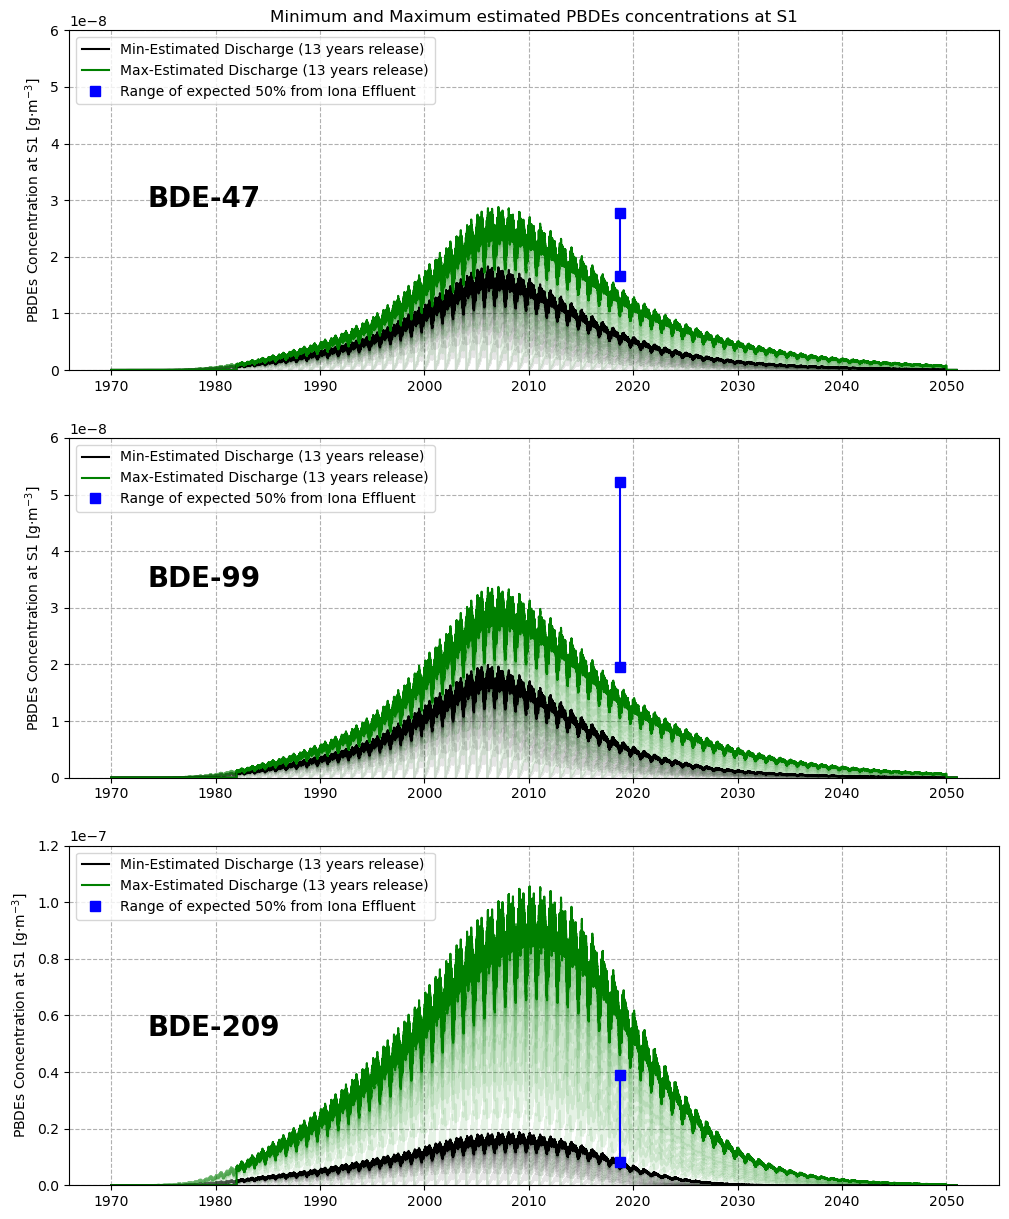

In [23]:
fig, ax = plt.subplots(3,1, figsize = (12, 15))
ax[0].plot(time_S1, min_BDE_47_S1*conversion_S1, 'k', alpha = .1)
ax[0].plot(time_S1, max_BDE_47_S1*conversion_S1, 'g', alpha = .1)
ax[0].plot(time_S1, min_BDE_47_S1['Year 12']*conversion_S1, 'k', label = 'Min-Estimated Discharge (13 years release)')
ax[0].plot(time_S1, max_BDE_47_S1['Year 12']*conversion_S1, 'g', label = 'Max-Estimated Discharge (13 years release)')
#ax[0].plot(year_expected_apr, values_apr_expected_47, '-r', markersize=10)
ax[0].plot(year_expected_aug, values_aug_expected_47, '-b')
ax[0].plot(year_expected_aug, values_aug_expected_47, 'sb', markersize=7, label = 'Range of expected ' + f'{int(factor*100)}% from Iona Effluent')
ax[0].set_ylim(0,6e-8)
ax[0].text(time_S1[5000],max_BDE_47_S1['Year 12'].max()*conversion_S1,'BDE-47', fontsize = 20, fontweight='bold')

#
ax[1].plot(time_S1, min_BDE_99_S1*conversion_S1, 'k', alpha = .1)
ax[1].plot(time_S1, max_BDE_99_S1*conversion_S1, 'g', alpha = .1)
ax[1].plot(time_S1, min_BDE_99_S1['Year 12']*conversion_S1, 'k', label = 'Min-Estimated Discharge (13 years release)')
ax[1].plot(time_S1, max_BDE_99_S1['Year 12']*conversion_S1, 'g', label = 'Max-Estimated Discharge (13 years release)')
#ax[1].plot(year_expected_apr, values_apr_expected_99, '-r', markersize=10)
ax[1].plot(year_expected_aug, values_aug_expected_99, '-b')
ax[1].plot(year_expected_aug, values_aug_expected_99, 'sb', markersize=7, label = 'Range of expected ' + f'{int(factor*100)}% from Iona Effluent')
ax[1].set_ylim(0,6e-8)
ax[1].text(time_S1[5000],max_BDE_99_S1['Year 12'].max()*conversion_S1,'BDE-99', fontsize = 20, fontweight='bold')

#
ax[2].plot(time_S1, min_BDE_209_S1*conversion_S1, 'k', alpha = .1)
ax[2].plot(time_S1, max_BDE_209_S1*conversion_S1, 'g', alpha = .1)
ax[2].plot(time_S1, min_BDE_209_S1['Year 12']*conversion_S1, 'k', label = 'Min-Estimated Discharge (13 years release)')
ax[2].plot(time_S1, max_BDE_209_S1['Year 12']*conversion_S1, 'g', label = 'Max-Estimated Discharge (13 years release)')
#ax[2].plot(year_expected_apr, values_apr_expected_209, '-r', markersize=10)
ax[2].plot(year_expected_aug, values_aug_expected_209, '-b')
ax[2].plot(year_expected_aug, values_aug_expected_209, 'sb', markersize=7, label = 'Range of expected ' + f'{int(factor*100)}% from Iona Effluent')
ax[2].set_ylim(0,1.2e-7)
ax[2].text(time_S1[5000],max_BDE_209_S1['Year 12'].max()*conversion_S1/2,'BDE-209', fontsize = 20, fontweight='bold')

#
for axis in ax:
    axis.grid(linestyle = '--')
    axis.legend(loc = 'upper left')
    axis.set_ylabel(r'PBDEs Concentration at S1 [g$\cdot$m$^{-3}$]')

ax[0].set_title('Minimum and Maximum estimated PBDEs concentrations at S1')    

# Extrapolation

In [24]:
extrapolated_S1_BDE_47_min, extrapolated_S1_BDE_47_max = long_term_functions.extrapolation_regional(congener_min=PBDEs_min, congener_max=PBDEs_max, 
                                                                                             polygon_lon_lat=polygon_lon_lat_S1, BDE_name='BDE-47')
#
pred_min_BDE_47_S1 = pd.DataFrame(extrapolated_S1_BDE_47_min, columns = ['BDE-47'])
pred_max_BDE_47_S1 = pd.DataFrame(extrapolated_S1_BDE_47_max, columns = ['BDE-47'])

In [25]:
extrapolated_S1_BDE_99_min, extrapolated_S1_BDE_99_max = long_term_functions.extrapolation_regional(congener_min=PBDEs_min, congener_max=PBDEs_max, 
                                                                                             polygon_lon_lat=polygon_lon_lat_S1, BDE_name='BDE-99')
#
pred_min_BDE_99_S1 = pd.DataFrame(extrapolated_S1_BDE_99_min, columns = ['BDE-99'])
pred_max_BDE_99_S1 = pd.DataFrame(extrapolated_S1_BDE_99_max, columns = ['BDE-99'])

In [26]:
extrapolated_S1_BDE_209_min, extrapolated_S1_BDE_209_max = long_term_functions.extrapolation_regional(congener_min=PBDEs_min, congener_max=PBDEs_max, 
                                                                                             polygon_lon_lat=polygon_lon_lat_S1, BDE_name='BDE-209')
#
pred_min_BDE_209_S1 = pd.DataFrame(extrapolated_S1_BDE_209_min, columns = ['BDE-99'])
pred_max_BDE_209_S1 = pd.DataFrame(extrapolated_S1_BDE_209_max, columns = ['BDE-99'])

In [27]:
time_S1_pred = np.arange(1970, max_year, 1/1460)

Text(0.5, 1.0, 'Minimum and Maximum estimated PBDEs concentrations at S1')

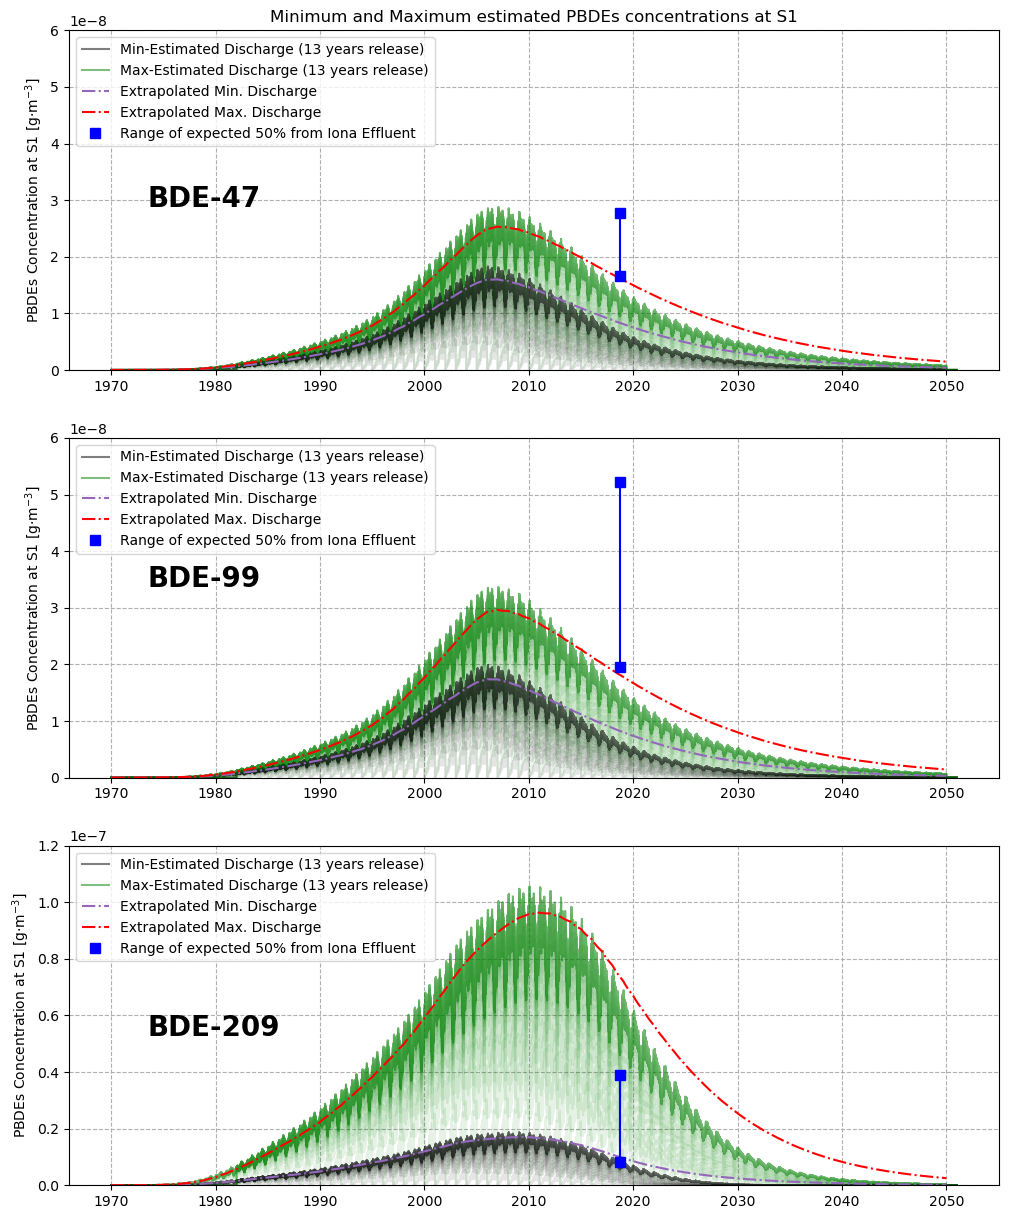

In [57]:
fig, ax = plt.subplots(3,1, figsize = (12, 15))
ax[0].plot(time_S1, min_BDE_47_S1*conversion_S1, 'k', alpha = .1)
ax[0].plot(time_S1, max_BDE_47_S1*conversion_S1, 'g', alpha = .1)
ax[0].plot(time_S1, min_BDE_47_S1['Year 12']*conversion_S1, 'k', alpha = .5, label = 'Min-Estimated Discharge (13 years release)')
ax[0].plot(time_S1, max_BDE_47_S1['Year 12']*conversion_S1, 'g', alpha = .5, label = 'Max-Estimated Discharge (13 years release)')
#
ax[0].plot(time_S1_pred, pred_min_BDE_47_S1*conversion_S1, c = 'tab:purple', linestyle = '-.', label = 'Extrapolated Min. Discharge')
ax[0].plot(time_S1_pred, pred_max_BDE_47_S1*conversion_S1, '-.r', label = 'Extrapolated Max. Discharge')
#
#ax[0].plot(year_expected_apr, values_apr_expected_47, '-r', markersize=10)
ax[0].plot(year_expected_aug, values_aug_expected_47, '-b')
ax[0].plot(year_expected_aug, values_aug_expected_47, 'sb', markersize=7, label = 'Range of expected ' + f'{int(factor*100)}% from Iona Effluent')
ax[0].set_ylim(0,6e-8)
ax[0].text(time_S1[5000],max_BDE_47_S1['Year 12'].max()*conversion_S1,'BDE-47', fontsize = 20, fontweight='bold')

#
ax[1].plot(time_S1, min_BDE_99_S1*conversion_S1, 'k', alpha = .1)
ax[1].plot(time_S1, max_BDE_99_S1*conversion_S1, 'g', alpha = .1)
ax[1].plot(time_S1, min_BDE_99_S1['Year 12']*conversion_S1, 'k', alpha = .5, label = 'Min-Estimated Discharge (13 years release)')
ax[1].plot(time_S1, max_BDE_99_S1['Year 12']*conversion_S1, 'g', alpha = .5, label = 'Max-Estimated Discharge (13 years release)')
#
ax[1].plot(time_S1_pred, pred_min_BDE_99_S1*conversion_S1, c = 'tab:purple', linestyle = '-.', label = 'Extrapolated Min. Discharge')
ax[1].plot(time_S1_pred, pred_max_BDE_99_S1*conversion_S1, '-.r', label = 'Extrapolated Max. Discharge')
#
#ax[1].plot(year_expected_apr, values_apr_expected_99, '-r', markersize=10)
ax[1].plot(year_expected_aug, values_aug_expected_99, '-b')
ax[1].plot(year_expected_aug, values_aug_expected_99, 'sb', markersize=7, label = 'Range of expected ' + f'{int(factor*100)}% from Iona Effluent')
ax[1].set_ylim(0,6e-8)
ax[1].text(time_S1[5000],max_BDE_99_S1['Year 12'].max()*conversion_S1,'BDE-99', fontsize = 20, fontweight='bold')

#
ax[2].plot(time_S1, min_BDE_209_S1*conversion_S1, 'k', alpha = .1)
ax[2].plot(time_S1, max_BDE_209_S1*conversion_S1, 'g', alpha = .1)
ax[2].plot(time_S1, min_BDE_209_S1['Year 12']*conversion_S1, 'k', alpha = .5, label = 'Min-Estimated Discharge (13 years release)')
ax[2].plot(time_S1, max_BDE_209_S1['Year 12']*conversion_S1, 'g', alpha = .5, label = 'Max-Estimated Discharge (13 years release)')
#
ax[2].plot(time_S1_pred, pred_min_BDE_209_S1*conversion_S1, c = 'tab:purple', linestyle = '-.', label = 'Extrapolated Min. Discharge')
ax[2].plot(time_S1_pred, pred_max_BDE_209_S1*conversion_S1, '-.r', label = 'Extrapolated Max. Discharge')
#
#ax[2].plot(year_expected_apr, values_apr_expected_209, '-r', markersize=10)
ax[2].plot(year_expected_aug, values_aug_expected_209, '-b')
ax[2].plot(year_expected_aug, values_aug_expected_209, 'sb', markersize=7, label = 'Range of expected ' + f'{int(factor*100)}% from Iona Effluent')
ax[2].set_ylim(0,1.2e-7)
ax[2].text(time_S1[5000],max_BDE_209_S1['Year 12'].max()*conversion_S1/2,'BDE-209', fontsize = 20, fontweight='bold')

#
for axis in ax:
    axis.grid(linestyle = '--')
    axis.legend(loc = 'upper left')
    axis.set_ylabel(r'PBDEs Concentration at S1 [g$\cdot$m$^{-3}$]')

ax[0].set_title('Minimum and Maximum estimated PBDEs concentrations at S1')    

# Region N1

In [29]:
from Regions_functions_V2 import polygon_N1, polygon_lon_lat_N1

In [30]:
volume_N1 = volume_region_50m_bottom(polygon_N1)

In [31]:
time_N1 = np.arange(1970, max_year+1, 1/(4*365))

In [32]:
N1_BDE_47_min, N1_BDE_47_max = long_term_functions.regions_tseries(congener_min=PBDEs_min, congener_max=PBDEs_max, polygon_lon_lat=polygon_lon_lat_N1, BDE_name='BDE-47')
#
min_BDE_47_N1 = pd.DataFrame(dict(zip(column_names, N1_BDE_47_min)))
max_BDE_47_N1 = pd.DataFrame(dict(zip(column_names, N1_BDE_47_max)))

In [33]:
N1_BDE_99_min, N1_BDE_99_max = long_term_functions.regions_tseries(congener_min=PBDEs_min, congener_max=PBDEs_max, polygon_lon_lat=polygon_lon_lat_N1, BDE_name='BDE-99')
#
min_BDE_99_N1 = pd.DataFrame(dict(zip(column_names, N1_BDE_99_min)))
max_BDE_99_N1 = pd.DataFrame(dict(zip(column_names, N1_BDE_99_max)))

In [34]:
N1_BDE_209_min, N1_BDE_209_max = long_term_functions.regions_tseries(congener_min=PBDEs_min, congener_max=PBDEs_max, polygon_lon_lat=polygon_lon_lat_N1, BDE_name='BDE-209')
#
min_BDE_209_N1 = pd.DataFrame(dict(zip(column_names, N1_BDE_209_min)))
max_BDE_209_N1 = pd.DataFrame(dict(zip(column_names, N1_BDE_209_max)))

In [35]:
conversion_N1 = (1/96) / volume_N1

In [36]:
c = 1e-12*1024
year_expected_aug_N1 = [2018.7, 2018.7]
values_aug_expected_47_N1 = [(7.7-0.2) * c * factor, (7.7+0.2) * c * factor]
#
values_aug_expected_99_N1 = [(1.9-0.2) * c * factor, (1.9+0.2) * c * factor]
#
values_aug_expected_209_N1 = [(26.9-3.2) * c * factor, (26.9+3.2) * c * factor]

Text(0.5, 1.0, 'Minimum and Maximum estimated PBDEs concentrations at N1')

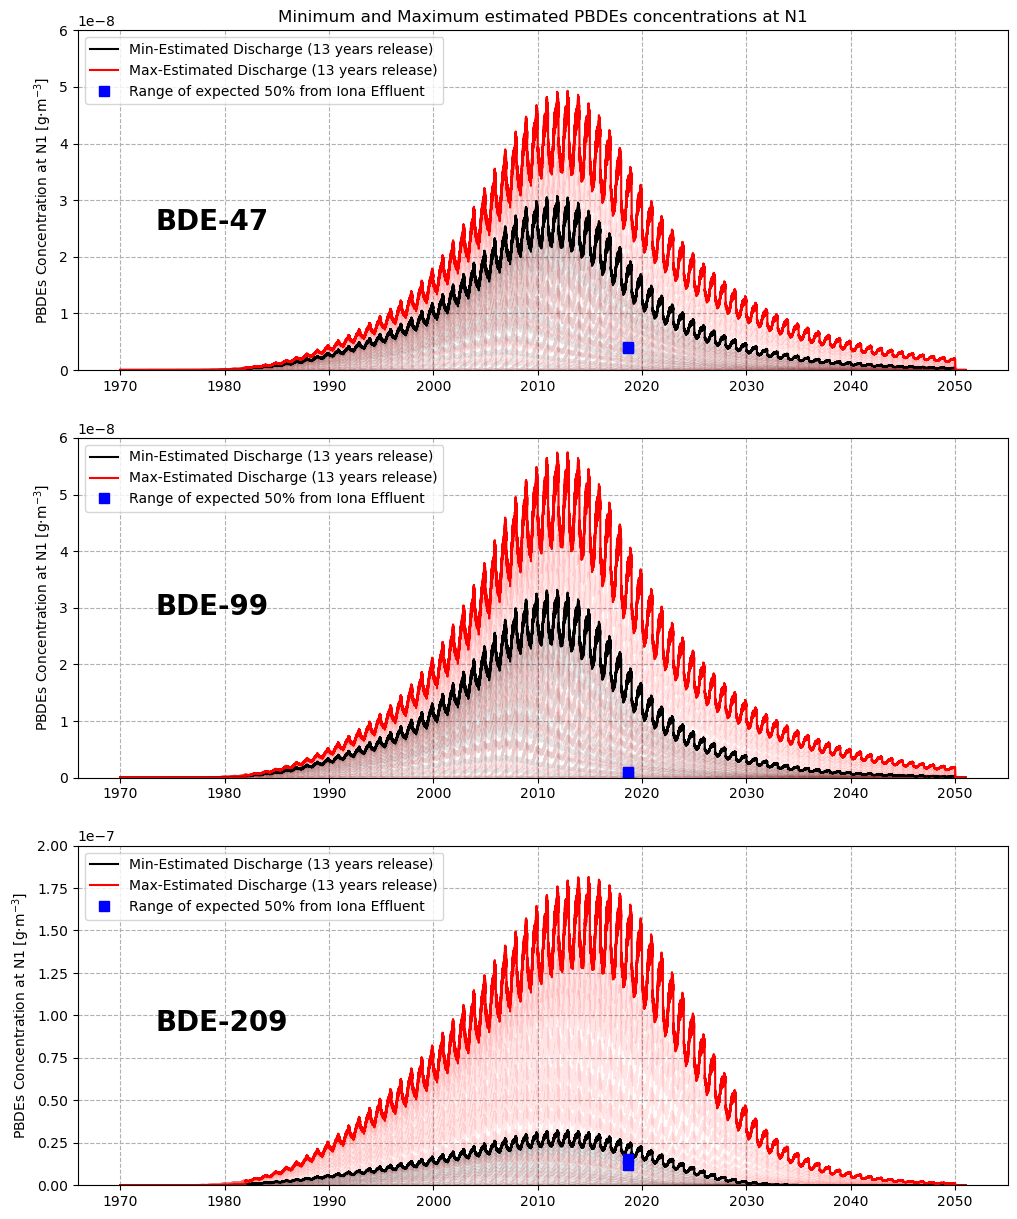

In [37]:
fig, ax = plt.subplots(3,1, figsize = (12, 15))
ax[0].plot(time_N1, min_BDE_47_N1*conversion_N1, 'k', alpha = .1)
ax[0].plot(time_N1, max_BDE_47_N1*conversion_N1, 'r', alpha = .1)
ax[0].plot(time_N1, min_BDE_47_N1['Year 12']*conversion_N1, 'k', label = 'Min-Estimated Discharge (13 years release)')
ax[0].plot(time_N1, max_BDE_47_N1['Year 12']*conversion_N1, 'r', label = 'Max-Estimated Discharge (13 years release)')
#ax[0].plot(year_expected_apr, values_apr_expected_47, '-r', markersize=10)
ax[0].plot(year_expected_aug_N1, values_aug_expected_47_N1, '-b')
ax[0].plot(year_expected_aug_N1, values_aug_expected_47_N1, 'sb', markersize=7, label = 'Range of expected ' + f'{int(factor*100)}% from Iona Effluent')
ax[0].set_ylim(0,6e-8)
ax[0].text(time_N1[5000],max_BDE_47_N1['Year 12'].max()*conversion_N1/2,'BDE-47', fontsize = 20, fontweight='bold')

#
ax[1].plot(time_N1, min_BDE_99_N1*conversion_N1, 'k', alpha = .1)
ax[1].plot(time_N1, max_BDE_99_N1*conversion_N1, 'r', alpha = .1)
ax[1].plot(time_N1, min_BDE_99_N1['Year 12']*conversion_N1, 'k', label = 'Min-Estimated Discharge (13 years release)')
ax[1].plot(time_N1, max_BDE_99_N1['Year 12']*conversion_N1, 'r', label = 'Max-Estimated Discharge (13 years release)')
#ax[1].plot(year_expected_apr, values_apr_expected_99, '-r', markersize=10)
ax[1].plot(year_expected_aug_N1, values_aug_expected_99_N1, '-b')
ax[1].plot(year_expected_aug_N1, values_aug_expected_99_N1, 'sb', markersize=7, label = 'Range of expected ' + f'{int(factor*100)}% from Iona Effluent')
ax[1].set_ylim(0,6e-8)
ax[1].text(time_N1[5000],max_BDE_99_N1['Year 12'].max()*conversion_N1/2,'BDE-99', fontsize = 20, fontweight='bold')

#
ax[2].plot(time_N1, min_BDE_209_N1*conversion_N1, 'k', alpha = .1)
ax[2].plot(time_N1, max_BDE_209_N1*conversion_N1, 'r', alpha = .1)
ax[2].plot(time_N1, min_BDE_209_N1['Year 12']*conversion_N1, 'k', label = 'Min-Estimated Discharge (13 years release)')
ax[2].plot(time_N1, max_BDE_209_N1['Year 12']*conversion_N1, 'r', label = 'Max-Estimated Discharge (13 years release)')
#ax[2].plot(year_expected_apr, values_apr_expected_209, '-r', markersize=10)
ax[2].plot(year_expected_aug_N1, values_aug_expected_209_N1, '-b')
ax[2].plot(year_expected_aug_N1, values_aug_expected_209_N1, 'sb', markersize=7, label = 'Range of expected ' + f'{int(factor*100)}% from Iona Effluent')
ax[2].set_ylim(0,2e-7)
ax[2].text(time_N1[5000],max_BDE_209_N1['Year 12'].max()*conversion_N1/2,'BDE-209', fontsize = 20, fontweight='bold')

#
for axis in ax:
    axis.grid(linestyle = '--')
    axis.legend(loc = 'upper left')
    axis.set_ylabel(r'PBDEs Concentration at N1 [g$\cdot$m$^{-3}$]')

ax[0].set_title('Minimum and Maximum estimated PBDEs concentrations at N1')    

# Extrapolation

In [38]:
extrapolated_N1_BDE_47_min, extrapolated_N1_BDE_47_max = long_term_functions.extrapolation_regional(congener_min=PBDEs_min, congener_max=PBDEs_max, 
                                                                                             polygon_lon_lat=polygon_lon_lat_N1, BDE_name='BDE-47')
#
pred_min_BDE_47_N1 = pd.DataFrame(extrapolated_N1_BDE_47_min, columns = ['BDE-47'])
pred_max_BDE_47_N1 = pd.DataFrame(extrapolated_N1_BDE_47_max, columns = ['BDE-47'])

In [39]:
extrapolated_N1_BDE_99_min, extrapolated_N1_BDE_99_max = long_term_functions.extrapolation_regional(congener_min=PBDEs_min, congener_max=PBDEs_max, 
                                                                                             polygon_lon_lat=polygon_lon_lat_N1, BDE_name='BDE-99')
#
pred_min_BDE_99_N1 = pd.DataFrame(extrapolated_N1_BDE_99_min, columns = ['BDE-99'])
pred_max_BDE_99_N1 = pd.DataFrame(extrapolated_N1_BDE_99_max, columns = ['BDE-99'])

In [40]:
extrapolated_N1_BDE_209_min, extrapolated_N1_BDE_209_max = long_term_functions.extrapolation_regional(congener_min=PBDEs_min, congener_max=PBDEs_max, 
                                                                                             polygon_lon_lat=polygon_lon_lat_N1, BDE_name='BDE-209')
#
pred_min_BDE_209_N1 = pd.DataFrame(extrapolated_N1_BDE_209_min, columns = ['BDE-209'])
pred_max_BDE_209_N1 = pd.DataFrame(extrapolated_N1_BDE_209_max, columns = ['BDE-209'])

Text(0.5, 1.0, 'Minimum and Maximum estimated PBDEs concentrations at N1')

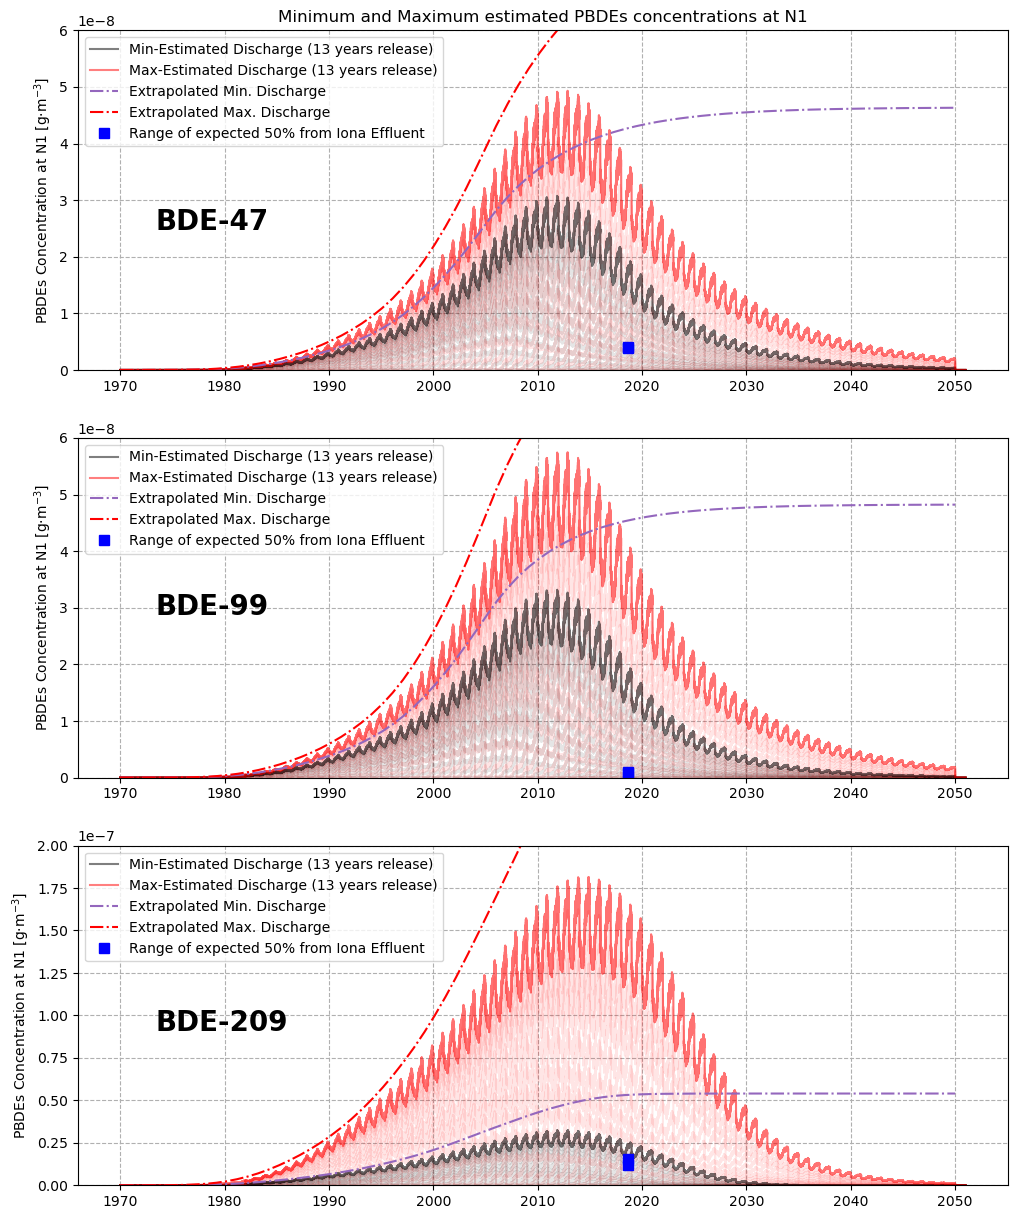

In [58]:
fig, ax = plt.subplots(3,1, figsize = (12, 15))
ax[0].plot(time_N1, min_BDE_47_N1*conversion_N1, 'k', alpha = .1)
ax[0].plot(time_N1, max_BDE_47_N1*conversion_N1, 'r', alpha = .1)
ax[0].plot(time_N1, min_BDE_47_N1['Year 12']*conversion_N1, 'k', alpha = .5, label = 'Min-Estimated Discharge (13 years release)')
ax[0].plot(time_N1, max_BDE_47_N1['Year 12']*conversion_N1, 'r', alpha = .5, label = 'Max-Estimated Discharge (13 years release)')
#
ax[0].plot(time_S1_pred, pred_min_BDE_47_N1*conversion_N1, c = 'tab:purple', linestyle = '-.', label = 'Extrapolated Min. Discharge')
ax[0].plot(time_S1_pred, pred_max_BDE_47_N1*conversion_N1, '-.r', label = 'Extrapolated Max. Discharge')
#
#ax[0].plot(year_expected_apr, values_apr_expected_47, '-r', markersize=10)
ax[0].plot(year_expected_aug_N1, values_aug_expected_47_N1, '-b')
ax[0].plot(year_expected_aug_N1, values_aug_expected_47_N1, 'sb', markersize=7, label = 'Range of expected ' + f'{int(factor*100)}% from Iona Effluent')
ax[0].set_ylim(0,6e-8)
ax[0].text(time_N1[5000],max_BDE_47_N1['Year 12'].max()*conversion_N1/2,'BDE-47', fontsize = 20, fontweight='bold')

#
ax[1].plot(time_N1, min_BDE_99_N1*conversion_N1, 'k', alpha = .1)
ax[1].plot(time_N1, max_BDE_99_N1*conversion_N1, 'r', alpha = .1)
ax[1].plot(time_N1, min_BDE_99_N1['Year 12']*conversion_N1, 'k', alpha = .5, label = 'Min-Estimated Discharge (13 years release)')
ax[1].plot(time_N1, max_BDE_99_N1['Year 12']*conversion_N1, 'r', alpha = .5, label = 'Max-Estimated Discharge (13 years release)')
#
ax[1].plot(time_S1_pred, pred_min_BDE_99_N1*conversion_N1, c = 'tab:purple', linestyle = '-.', label = 'Extrapolated Min. Discharge')
ax[1].plot(time_S1_pred, pred_max_BDE_99_N1*conversion_N1, '-.r', label = 'Extrapolated Max. Discharge')
#
#ax[1].plot(year_expected_apr, values_apr_expected_99, '-r', markersize=10)
ax[1].plot(year_expected_aug_N1, values_aug_expected_99_N1, '-b')
ax[1].plot(year_expected_aug_N1, values_aug_expected_99_N1, 'sb', markersize=7, label = 'Range of expected ' + f'{int(factor*100)}% from Iona Effluent')
ax[1].set_ylim(0,6e-8)
ax[1].text(time_N1[5000],max_BDE_99_N1['Year 12'].max()*conversion_N1/2,'BDE-99', fontsize = 20, fontweight='bold')

#
ax[2].plot(time_N1, min_BDE_209_N1*conversion_N1, 'k', alpha = .1)
ax[2].plot(time_N1, max_BDE_209_N1*conversion_N1, 'r', alpha = .1)
ax[2].plot(time_N1, min_BDE_209_N1['Year 12']*conversion_N1, 'k', alpha = .5, label = 'Min-Estimated Discharge (13 years release)')
ax[2].plot(time_N1, max_BDE_209_N1['Year 12']*conversion_N1, 'r', alpha = .5, label = 'Max-Estimated Discharge (13 years release)')
#
ax[2].plot(time_S1_pred, pred_min_BDE_209_N1*conversion_N1, c = 'tab:purple', linestyle = '-.', label = 'Extrapolated Min. Discharge')
ax[2].plot(time_S1_pred, pred_max_BDE_209_N1*conversion_N1, '-.r', label = 'Extrapolated Max. Discharge')
#
#ax[2].plot(year_expected_apr, values_apr_expected_209, '-r', markersize=10)
ax[2].plot(year_expected_aug_N1, values_aug_expected_209_N1, '-b')
ax[2].plot(year_expected_aug_N1, values_aug_expected_209_N1, 'sb', markersize=7, label = 'Range of expected ' + f'{int(factor*100)}% from Iona Effluent')
ax[2].set_ylim(0,2e-7)
ax[2].text(time_N1[5000],max_BDE_209_N1['Year 12'].max()*conversion_N1/2,'BDE-209', fontsize = 20, fontweight='bold')

#
for axis in ax:
    axis.grid(linestyle = '--')
    axis.legend(loc = 'upper left')
    axis.set_ylabel(r'PBDEs Concentration at N1 [g$\cdot$m$^{-3}$]')

ax[0].set_title('Minimum and Maximum estimated PBDEs concentrations at N1')    

# Region SP

In [42]:
from Regions_functions_V2 import polygon_SP, polygon_lon_lat_SP

In [43]:
volume_SP = volume_region_50m_bottom(polygon_SP)

In [44]:
time_SP = np.arange(1970, max_year+1, 1/(4*365))

In [45]:
SP_BDE_47_min, SP_BDE_47_max = long_term_functions.regions_tseries(congener_min=PBDEs_min, congener_max=PBDEs_max, polygon_lon_lat=polygon_lon_lat_SP, BDE_name='BDE-47')
#
min_BDE_47_SP = pd.DataFrame(dict(zip(column_names, SP_BDE_47_min)))
max_BDE_47_SP = pd.DataFrame(dict(zip(column_names, SP_BDE_47_max)))

In [46]:
SP_BDE_99_min, SP_BDE_99_max = long_term_functions.regions_tseries(congener_min=PBDEs_min, congener_max=PBDEs_max, polygon_lon_lat=polygon_lon_lat_SP, BDE_name='BDE-99')
#
min_BDE_99_SP = pd.DataFrame(dict(zip(column_names, SP_BDE_99_min)))
max_BDE_99_SP = pd.DataFrame(dict(zip(column_names, SP_BDE_99_max)))

In [47]:
SP_BDE_209_min, SP_BDE_209_max = long_term_functions.regions_tseries(congener_min=PBDEs_min, congener_max=PBDEs_max, polygon_lon_lat=polygon_lon_lat_SP, BDE_name='BDE-209')
#
min_BDE_209_SP = pd.DataFrame(dict(zip(column_names, SP_BDE_209_min)))
max_BDE_209_SP = pd.DataFrame(dict(zip(column_names, SP_BDE_209_max)))

In [48]:
conversion_SP = (1/96) / volume_SP

In [49]:
c = 1e-12*1024
year_expected_SP = [2014, 2014]
values_expected_47_SP = [(142.6-54.8) * c * factor, (142.6+54.8) * c * factor]
#
values_expected_99_SP = [(56.1-23.9) * c * factor, (56.1+23.9) * c * factor]
#
values_expected_209_SP = [(191.2-152.1) * c * factor, (191.2+152.1) * c * factor]

Text(0.5, 1.0, 'Minimum and Maximum estimated PBDEs concentrations at SP')

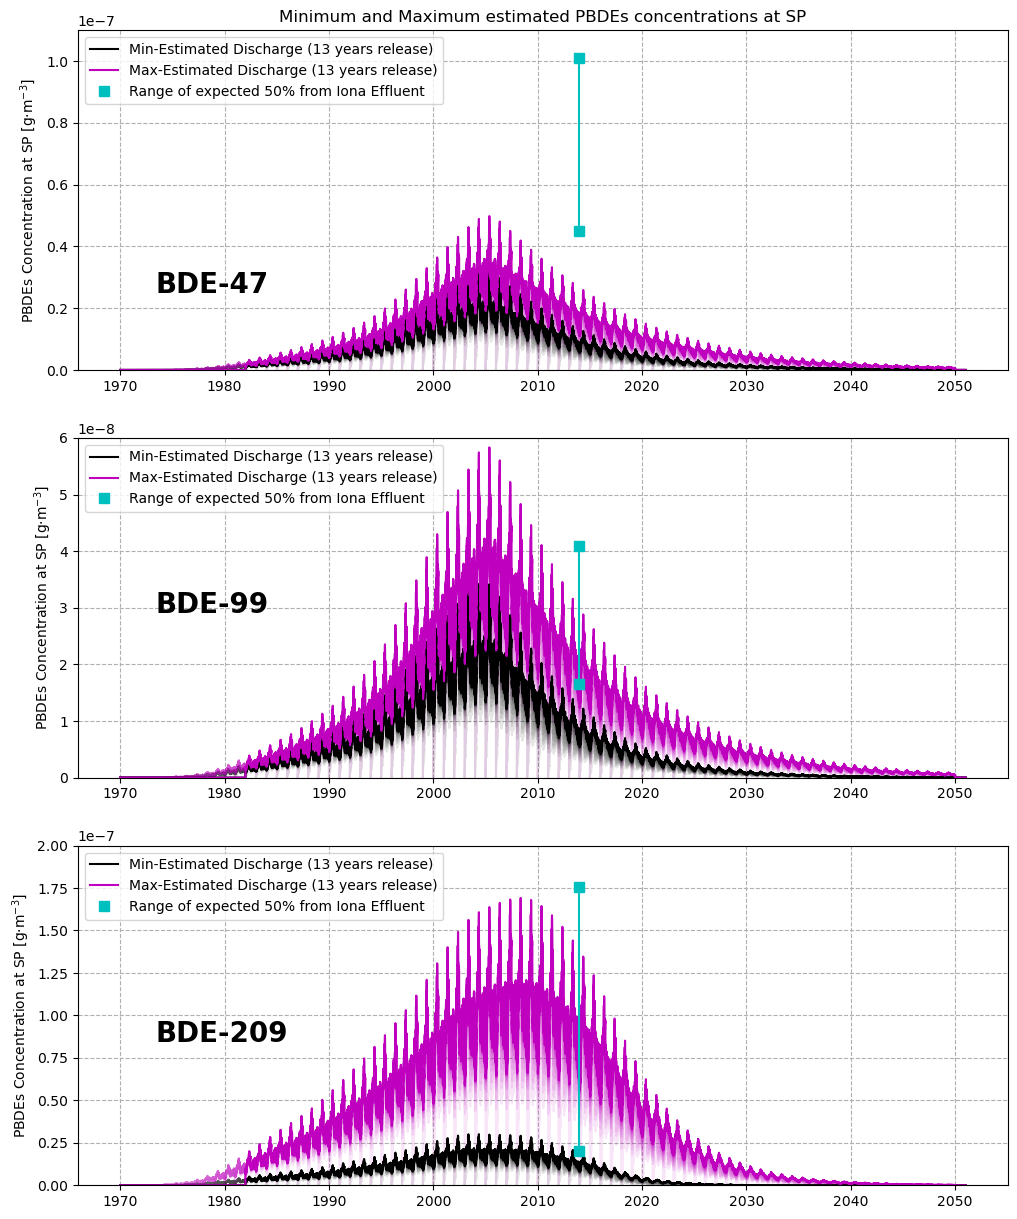

In [50]:
fig, ax = plt.subplots(3,1, figsize = (12, 15))
ax[0].plot(time_SP, min_BDE_47_SP*conversion_SP, 'k', alpha = .1)
ax[0].plot(time_SP, max_BDE_47_SP*conversion_SP, 'm', alpha = .1)
ax[0].plot(time_SP, min_BDE_47_SP['Year 12']*conversion_SP, 'k', label = 'Min-Estimated Discharge (13 years release)')
ax[0].plot(time_SP, max_BDE_47_SP['Year 12']*conversion_SP, 'm', label = 'Max-Estimated Discharge (13 years release)')
#ax[0].plot(year_expected_apr, values_apr_expected_47, '-r', markersize=10)
ax[0].plot(year_expected_SP, values_expected_47_SP, '-c')
ax[0].plot(year_expected_SP, values_expected_47_SP, 'sc', markersize=7, label = 'Range of expected ' + f'{int(factor*100)}% from Iona Effluent')
ax[0].set_ylim(0,11e-8)
ax[0].text(time_SP[5000],max_BDE_47_SP['Year 12'].max()*conversion_SP/2,'BDE-47', fontsize = 20, fontweight='bold')

#
ax[1].plot(time_SP, min_BDE_99_SP*conversion_SP, 'k', alpha = .1)
ax[1].plot(time_SP, max_BDE_99_SP*conversion_SP, 'm', alpha = .1)
ax[1].plot(time_SP, min_BDE_99_SP['Year 12']*conversion_SP, 'k', label = 'Min-Estimated Discharge (13 years release)')
ax[1].plot(time_SP, max_BDE_99_SP['Year 12']*conversion_SP, 'm', label = 'Max-Estimated Discharge (13 years release)')
#ax[1].plot(year_expected_apr, values_apr_expected_99, '-r', markersize=10)
ax[1].plot(year_expected_SP, values_expected_99_SP, '-c')
ax[1].plot(year_expected_SP, values_expected_99_SP, 'sc', markersize=7, label = 'Range of expected ' + f'{int(factor*100)}% from Iona Effluent')
ax[1].set_ylim(0,6e-8)
ax[1].text(time_SP[5000],max_BDE_99_SP['Year 12'].max()*conversion_SP/2,'BDE-99', fontsize = 20, fontweight='bold')

#
ax[2].plot(time_SP, min_BDE_209_SP*conversion_SP, 'k', alpha = .1)
ax[2].plot(time_SP, max_BDE_209_SP*conversion_SP, 'm', alpha = .1)
ax[2].plot(time_SP, min_BDE_209_SP['Year 12']*conversion_SP, 'k', label = 'Min-Estimated Discharge (13 years release)')
ax[2].plot(time_SP, max_BDE_209_SP['Year 12']*conversion_SP, 'm', label = 'Max-Estimated Discharge (13 years release)')
#ax[2].plot(year_expected_apr, values_apr_expected_209, '-r', markersize=10)
ax[2].plot(year_expected_SP, values_expected_209_SP, '-c')
ax[2].plot(year_expected_SP, values_expected_209_SP, 'sc', markersize=7, label = 'Range of expected ' + f'{int(factor*100)}% from Iona Effluent')
ax[2].set_ylim(0,2e-7)
ax[2].text(time_SP[5000],max_BDE_209_SP['Year 12'].max()*conversion_SP/2,'BDE-209', fontsize = 20, fontweight='bold')

#
for axis in ax:
    axis.grid(linestyle = '--')
    axis.legend(loc = 'upper left')
    axis.set_ylabel(r'PBDEs Concentration at SP [g$\cdot$m$^{-3}$]')

ax[0].set_title('Minimum and Maximum estimated PBDEs concentrations at SP')    

# Extrapolation

In [51]:
extrapolated_SP_BDE_47_min, extrapolated_SP_BDE_47_max = long_term_functions.extrapolation_regional(congener_min=PBDEs_min, congener_max=PBDEs_max, 
                                                                                             polygon_lon_lat=polygon_lon_lat_SP, BDE_name='BDE-47')
#
pred_min_BDE_47_SP = pd.DataFrame(extrapolated_SP_BDE_47_min, columns = ['BDE-47'])
pred_max_BDE_47_SP = pd.DataFrame(extrapolated_SP_BDE_47_max, columns = ['BDE-47'])

In [52]:
extrapolated_SP_BDE_99_min, extrapolated_SP_BDE_99_max = long_term_functions.extrapolation_regional(congener_min=PBDEs_min, congener_max=PBDEs_max, 
                                                                                             polygon_lon_lat=polygon_lon_lat_SP, BDE_name='BDE-99')
#
pred_min_BDE_99_SP = pd.DataFrame(extrapolated_SP_BDE_99_min, columns = ['BDE-99'])
pred_max_BDE_99_SP = pd.DataFrame(extrapolated_SP_BDE_99_max, columns = ['BDE-99'])

In [53]:
extrapolated_SP_BDE_209_min, extrapolated_SP_BDE_209_max = long_term_functions.extrapolation_regional(congener_min=PBDEs_min, congener_max=PBDEs_max, 
                                                                                             polygon_lon_lat=polygon_lon_lat_SP, BDE_name='BDE-209')
#
pred_min_BDE_209_SP = pd.DataFrame(extrapolated_SP_BDE_209_min, columns = ['BDE-209'])
pred_max_BDE_209_SP = pd.DataFrame(extrapolated_SP_BDE_209_max, columns = ['BDE-209'])

Text(0.5, 1.0, 'Minimum and Maximum estimated PBDEs concentrations at SP')

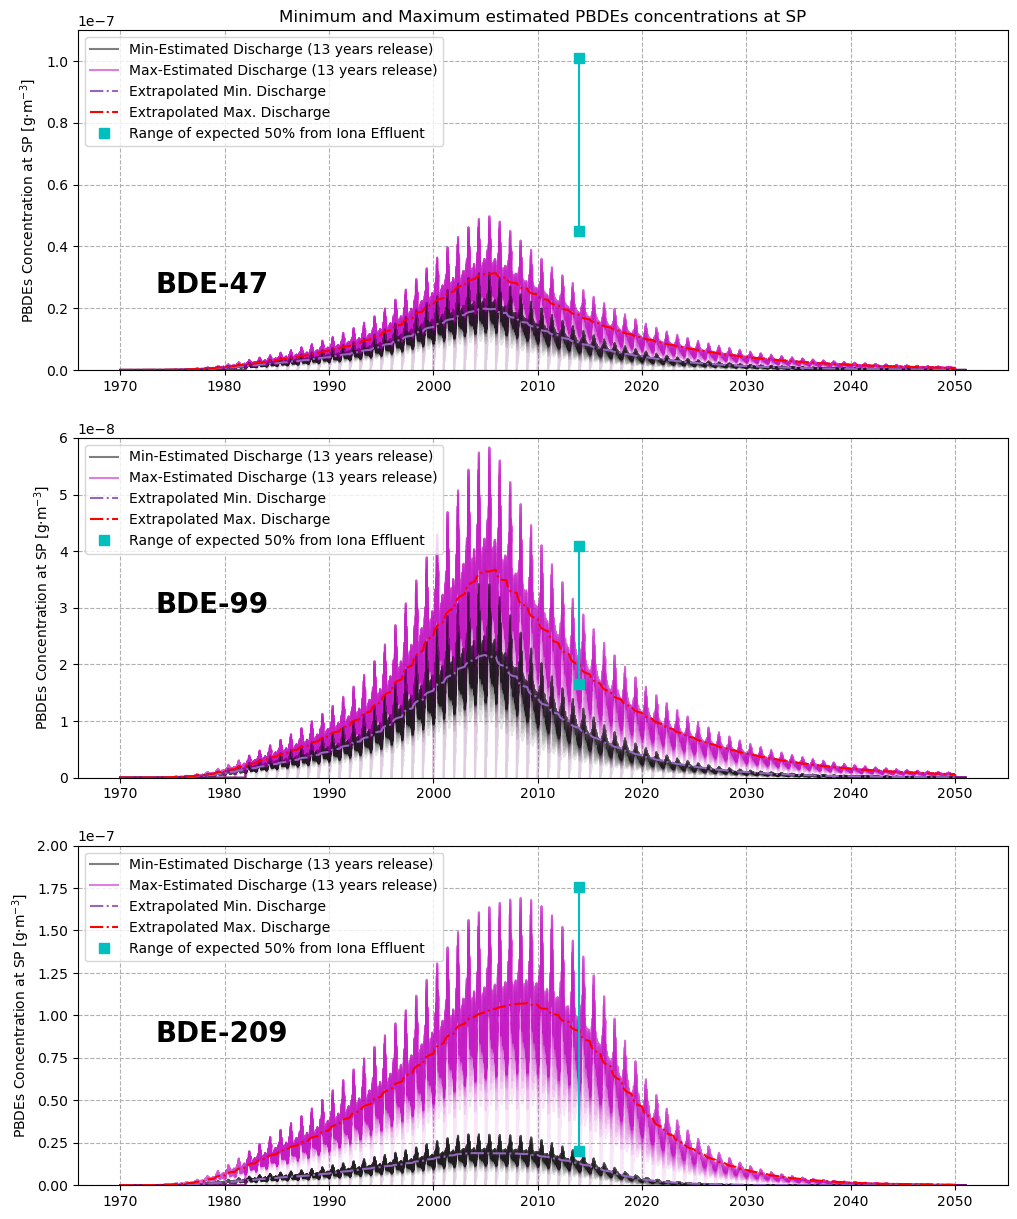

In [59]:
fig, ax = plt.subplots(3,1, figsize = (12, 15))
ax[0].plot(time_SP, min_BDE_47_SP*conversion_SP, 'k', alpha = .1)
ax[0].plot(time_SP, max_BDE_47_SP*conversion_SP, 'm', alpha = .1)
ax[0].plot(time_SP, min_BDE_47_SP['Year 12']*conversion_SP, 'k', alpha = .5, label = 'Min-Estimated Discharge (13 years release)')
ax[0].plot(time_SP, max_BDE_47_SP['Year 12']*conversion_SP, 'm', alpha = .5, label = 'Max-Estimated Discharge (13 years release)')
#
ax[0].plot(time_S1_pred, pred_min_BDE_47_SP*conversion_SP, c = 'tab:purple', linestyle = '-.', label = 'Extrapolated Min. Discharge')
ax[0].plot(time_S1_pred, pred_max_BDE_47_SP*conversion_SP, '-.r', label = 'Extrapolated Max. Discharge')
#
#ax[0].plot(year_expected_apr, values_apr_expected_47, '-r', markersize=10)
ax[0].plot(year_expected_SP, values_expected_47_SP, '-c')
ax[0].plot(year_expected_SP, values_expected_47_SP, 'sc', markersize=7, label = 'Range of expected ' + f'{int(factor*100)}% from Iona Effluent')
ax[0].set_ylim(0,11e-8)
ax[0].text(time_SP[5000],max_BDE_47_SP['Year 12'].max()*conversion_SP/2,'BDE-47', fontsize = 20, fontweight='bold')

#
ax[1].plot(time_SP, min_BDE_99_SP*conversion_SP, 'k', alpha = .1)
ax[1].plot(time_SP, max_BDE_99_SP*conversion_SP, 'm', alpha = .1)
ax[1].plot(time_SP, min_BDE_99_SP['Year 12']*conversion_SP, 'k', alpha = .5, label = 'Min-Estimated Discharge (13 years release)')
ax[1].plot(time_SP, max_BDE_99_SP['Year 12']*conversion_SP, 'm', alpha = .5, label = 'Max-Estimated Discharge (13 years release)')
#
ax[1].plot(time_S1_pred, pred_min_BDE_99_SP*conversion_SP, c = 'tab:purple', linestyle = '-.', label = 'Extrapolated Min. Discharge')
ax[1].plot(time_S1_pred, pred_max_BDE_99_SP*conversion_SP, '-.r', label = 'Extrapolated Max. Discharge')
#
#ax[1].plot(year_expected_apr, values_apr_expected_99, '-r', markersize=10)
ax[1].plot(year_expected_SP, values_expected_99_SP, '-c')
ax[1].plot(year_expected_SP, values_expected_99_SP, 'sc', markersize=7, label = 'Range of expected ' + f'{int(factor*100)}% from Iona Effluent')
ax[1].set_ylim(0,6e-8)
ax[1].text(time_SP[5000],max_BDE_99_SP['Year 12'].max()*conversion_SP/2,'BDE-99', fontsize = 20, fontweight='bold')

#
ax[2].plot(time_SP, min_BDE_209_SP*conversion_SP, 'k', alpha = .1)
ax[2].plot(time_SP, max_BDE_209_SP*conversion_SP, 'm', alpha = .1)
ax[2].plot(time_SP, min_BDE_209_SP['Year 12']*conversion_SP, 'k', alpha = .5, label = 'Min-Estimated Discharge (13 years release)')
ax[2].plot(time_SP, max_BDE_209_SP['Year 12']*conversion_SP, 'm', alpha = .5, label = 'Max-Estimated Discharge (13 years release)')
#
ax[2].plot(time_S1_pred, pred_min_BDE_209_SP*conversion_SP, c = 'tab:purple', linestyle = '-.', label = 'Extrapolated Min. Discharge')
ax[2].plot(time_S1_pred, pred_max_BDE_209_SP*conversion_SP, '-.r', label = 'Extrapolated Max. Discharge')
#
#ax[2].plot(year_expected_apr, values_apr_expected_209, '-r', markersize=10)
ax[2].plot(year_expected_SP, values_expected_209_SP, '-c')
ax[2].plot(year_expected_SP, values_expected_209_SP, 'sc', markersize=7, label = 'Range of expected ' + f'{int(factor*100)}% from Iona Effluent')
ax[2].set_ylim(0,2e-7)
ax[2].text(time_SP[5000],max_BDE_209_SP['Year 12'].max()*conversion_SP/2,'BDE-209', fontsize = 20, fontweight='bold')

#
for axis in ax:
    axis.grid(linestyle = '--')
    axis.legend(loc = 'upper left')
    axis.set_ylabel(r'PBDEs Concentration at SP [g$\cdot$m$^{-3}$]')

ax[0].set_title('Minimum and Maximum estimated PBDEs concentrations at SP')    

In [64]:
# Check for N1, it is not looking good. Change the fit. For SP too

In [60]:
file_year1 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_1.nc'
file_year2 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_2.nc'
file_year3 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_3.nc'
file_year4 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_4.nc'
file_year5 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_5.nc'
file_year6 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_6.nc'
file_year7 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_7.nc'
file_year8 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_8.nc'
file_year9 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_9.nc'
file_year10 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_10.nc'
file_year11 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_11.nc'
file_year12 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_12.nc'
file_year13 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_13.nc'
#
t_series_region = [long_term_functions.get_total_timeseries_optimized(file_year1, polygon_lon_lat_N1)['Total_Count'].values[::2],
                    long_term_functions.get_total_timeseries_optimized(file_year2, polygon_lon_lat_N1)['Total_Count'].values[::2],
                    long_term_functions.get_total_timeseries_optimized(file_year3, polygon_lon_lat_N1)['Total_Count'].values,
                    long_term_functions.get_total_timeseries_optimized(file_year4, polygon_lon_lat_N1)['Total_Count'].values,
                    long_term_functions.get_total_timeseries_optimized(file_year5, polygon_lon_lat_N1)['Total_Count'].values,
                    long_term_functions.get_total_timeseries_optimized(file_year6, polygon_lon_lat_N1)['Total_Count'].values,
                    long_term_functions.get_total_timeseries_optimized(file_year7, polygon_lon_lat_N1)['Total_Count'].values,
                    long_term_functions.get_total_timeseries_optimized(file_year8, polygon_lon_lat_N1)['Total_Count'].values,
                    long_term_functions.get_total_timeseries_optimized(file_year9, polygon_lon_lat_N1)['Total_Count'].values,
                    long_term_functions.get_total_timeseries_optimized(file_year10, polygon_lon_lat_N1)['Total_Count'].values,
                    long_term_functions.get_total_timeseries_optimized(file_year11, polygon_lon_lat_N1)['Total_Count'].values,
                    long_term_functions.get_total_timeseries_optimized(file_year12, polygon_lon_lat_N1)['Total_Count'].values,
                    long_term_functions.get_total_timeseries_optimized(file_year13, polygon_lon_lat_N1)['Total_Count'].values
                    ]

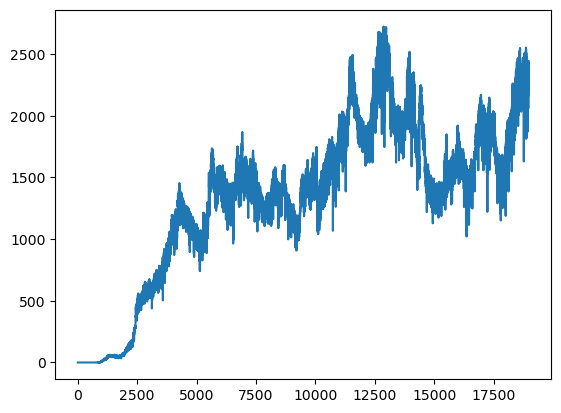

In [63]:
plt.plot(np.concatenate(t_series_region))